In [24]:
%pip install ultraplot xskillscore -q

Note: you may need to restart the kernel to use updated packages.


In [56]:
import datacube
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy
import ultraplot
import xskillscore
from matplotlib.dates import MonthLocator

import sys
sys.path.insert(1, '.../Tools')
from dea_tools.datahandling import load_ard
from dea_tools.plotting import rgb, display_map
from dea_tools.dask import create_local_dask_cluster
from dea_tools.bandindices import calculate_indices

In [2]:
create_local_dask_cluster()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 3,Total memory: 28.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44195,Workers: 1
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,Total threads: 3
Started: Just now,Total memory: 28.21 GiB
Comm: tcp://127.0.0.1:40811,Total threads: 3
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/33673/status,Memory: 28.21 GiB
Nanny: tcp://127.0.0.1:43349,


In [3]:
dc = datacube.Datacube(app="TCP_initial_exploration")

In [4]:
# calculate statistics over the individual TC scenes
def reduce(ds):
    yy = xr_quantile_bands(ds, [0.1, 0.5, 0.9], nodata=np.nan)
    return yy

In [5]:
lat = -35.4100
lon = 143.8040
buffer = 0.1


lat_range = (lat - buffer, lat + buffer)
lon_range = (lon - buffer, lon + buffer)

resolution = (-30, 30)
measurements = ["nbart_blue", "nbart_green", "nbart_red", "nbart_nir", "nbart_swir_1", "nbart_swir_2", "oa_fmask", "oa_nbart_contiguity"]
dask_chunks = dict(time=1, x=512, y=512)

In [6]:
# set up baseline dc query. THis will be modified by functions as needed later on.
query = {
    'x': lon_range,
    'y': lat_range,
    'time': ('2024-01', '2024-12'),
    'measurements': measurements,
    'resolution': resolution,
    'group_by': 'solar_day',
    'output_crs': 'EPSG:3577',
    'dask_chunks': dask_chunks,
}

In [7]:
ds = load_ard(
    dc=dc,
    products=['ga_ls8c_ard_3', 'ga_ls9c_ard_3'],
    cloud_mask = 'fmask',
    mask_pixel_quality=True,
    mask_contiguity = True,
    min_gooddata = 0.99,
    **query
)

Finding datasets
    ga_ls8c_ard_3
    ga_ls9c_ard_3
Counting good quality pixels for each time step using fmask


/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


Filtering to 24 out of 91 time steps with at least 99.0% good quality pixels
Applying fmask pixel quality/cloud mask
Applying contiguity mask (oa_nbart_contiguity)
Returning 24 time steps as a dask array


In [23]:
ds

<xarray.Dataset> Size: 332MB
Dimensions:              (time: 24, y: 794, x: 671)
Coordinates:
  * time                 (time) datetime64[ns] 192B 2024-02-01T00:15:18.81910...
  * y                    (y) float64 6kB -3.905e+06 -3.905e+06 ... -3.929e+06
  * x                    (x) float64 5kB 1.059e+06 1.059e+06 ... 1.079e+06
    spatial_ref          int32 4B 3577
Data variables:
    nbart_blue           (time, y, x) float32 51MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    nbart_green          (time, y, x) float32 51MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    nbart_red            (time, y, x) float32 51MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    nbart_nir            (time, y, x) float32 51MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    nbart_swir_1         (time, y, x) float32 51MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    nbart_swir_2         (time, y, x) float32 51MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    oa_fmask             (time, y, x) uint8 13MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    oa_nbart_contiguity  (time, y, x) uint8 13MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [9]:
#rgb(ds, col='time')

In [17]:
ds_tc = calculate_indices(ds, 
                          index=['TCW', 'TCB', 'TCG', 'TCW_ls8ls9', 'TCB_ls8ls9', 'TCG_ls8ls9'], 
                          drop=True,
                          collection = 'ga_ls_3').compute()

Dropping bands ['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir', 'nbart_swir_1', 'nbart_swir_2', 'oa_fmask', 'oa_nbart_contiguity']


In [11]:
# find difference between the two versions of the TC
difference = ds_tc['TCW'] - ds_tc['TCW_ls8ls9']

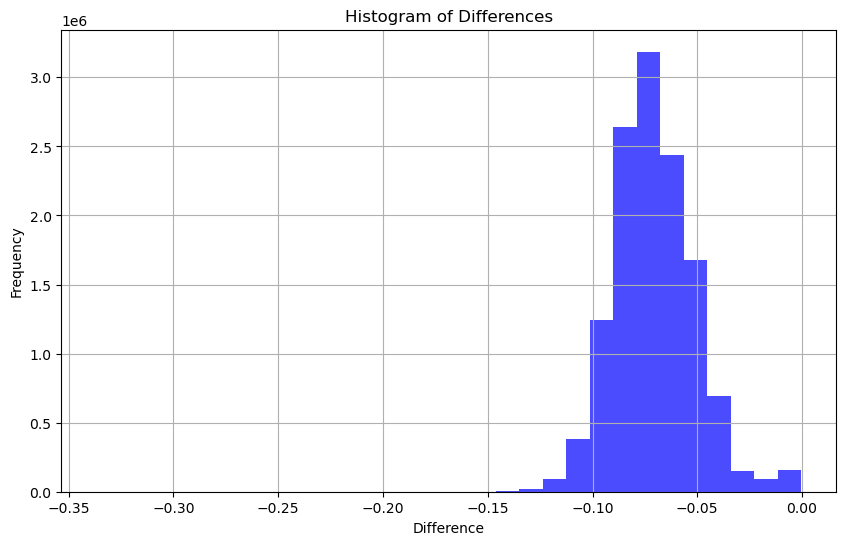

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(difference.values.flatten(), bins=30, color='blue', alpha=0.7)
plt.title("Histogram of Differences")
plt.xlabel("Difference")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

(-1.0, 0.25)

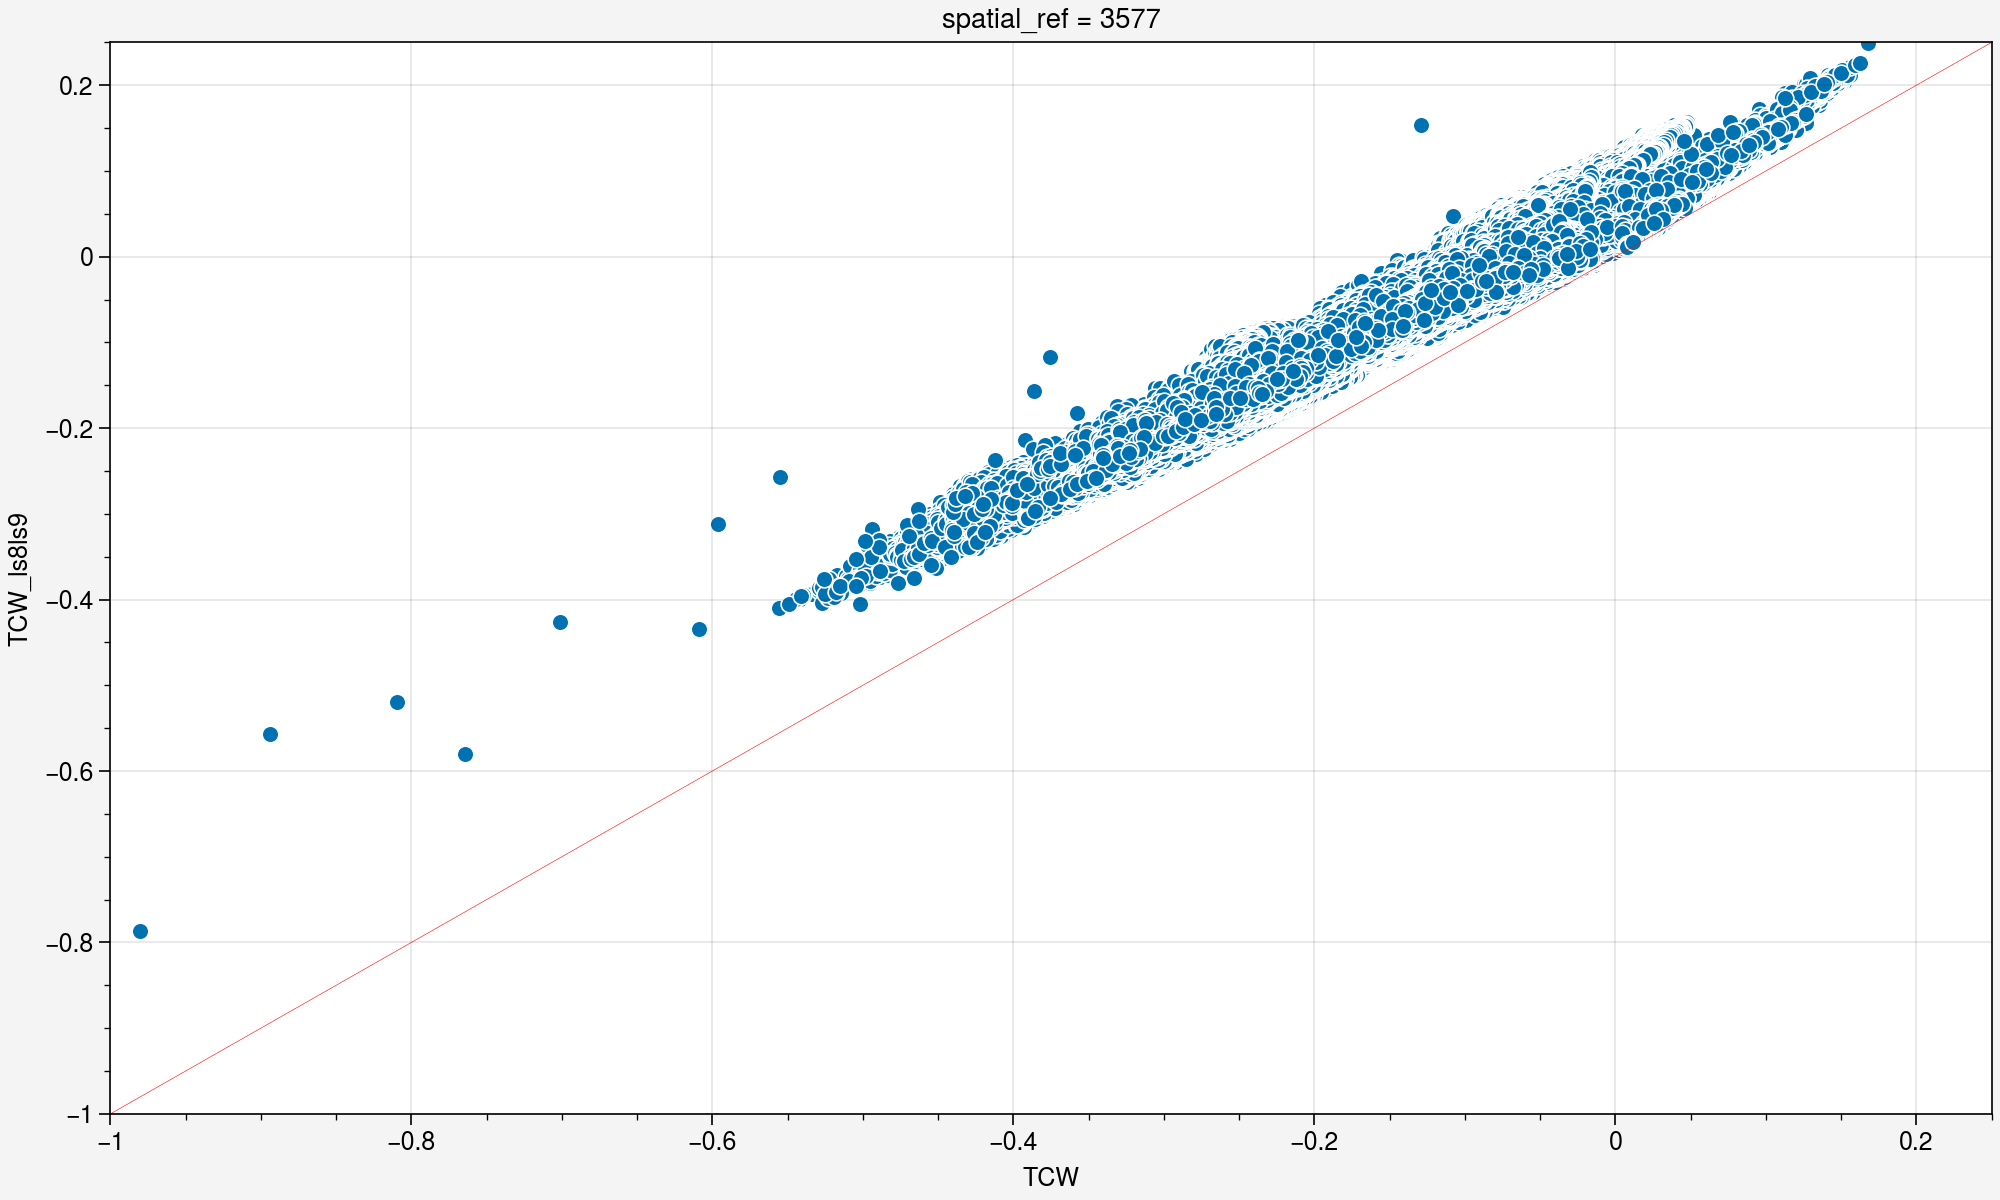

In [62]:
f, ax = plt.subplots(figsize=(10, 6), layout='constrained')
ds_tc.plot.scatter(x='TCW', y='TCW_ls8ls9', ax=ax)
ax.plot([-1, 1], [-1, 1], c='r', lw=0.2)
ax.set_xlim(-1, 0.25)
ax.set_ylim(-1, 0.25)


# plt.show()

Text(0.5, 1.0, '')

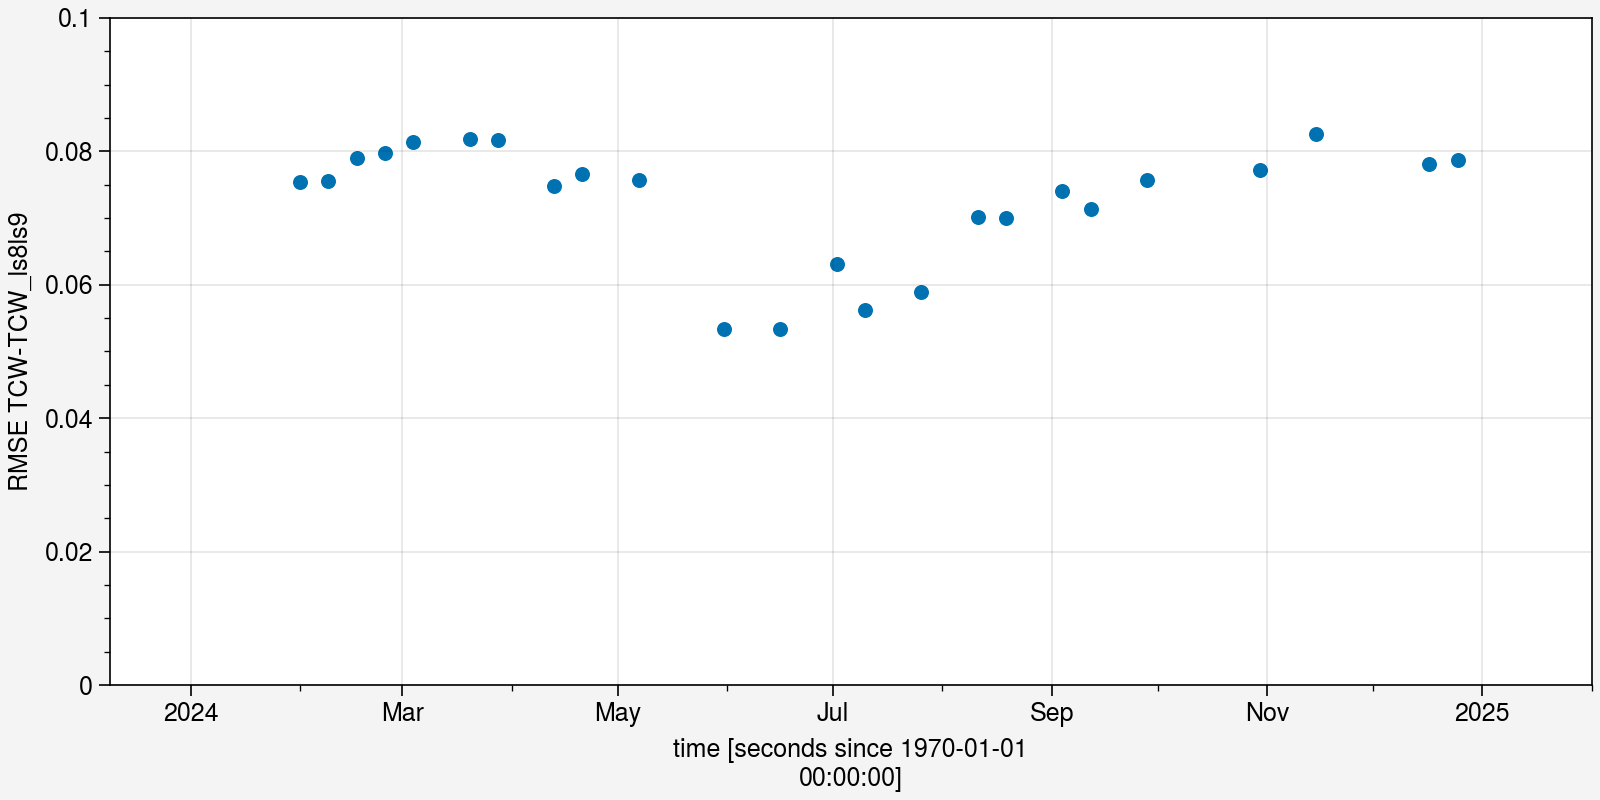

In [61]:
variables = ['TCW', 'TCW_ls8ls9']
a = ds_tc.stack(dims=['x', 'y'])[variables].dropna(
    dim='dims').groupby('time').apply(
    lambda x: xskillscore.rmse(x[variables[0]], x[variables[1]]))
f, ax = plt.subplots(figsize=(8, 4), layout='constrained')
a.plot.scatter(x='time', ax=ax)
ax.set_xlim(19700, 20120)
ax.xaxis.set_minor_locator(MonthLocator())
ax.set_ylim(0, 0.1)
ax.set_ylabel(f'RMSE {"-".join(variables)}')
ax.set_title('')


Text(0.5, 1.0, '')

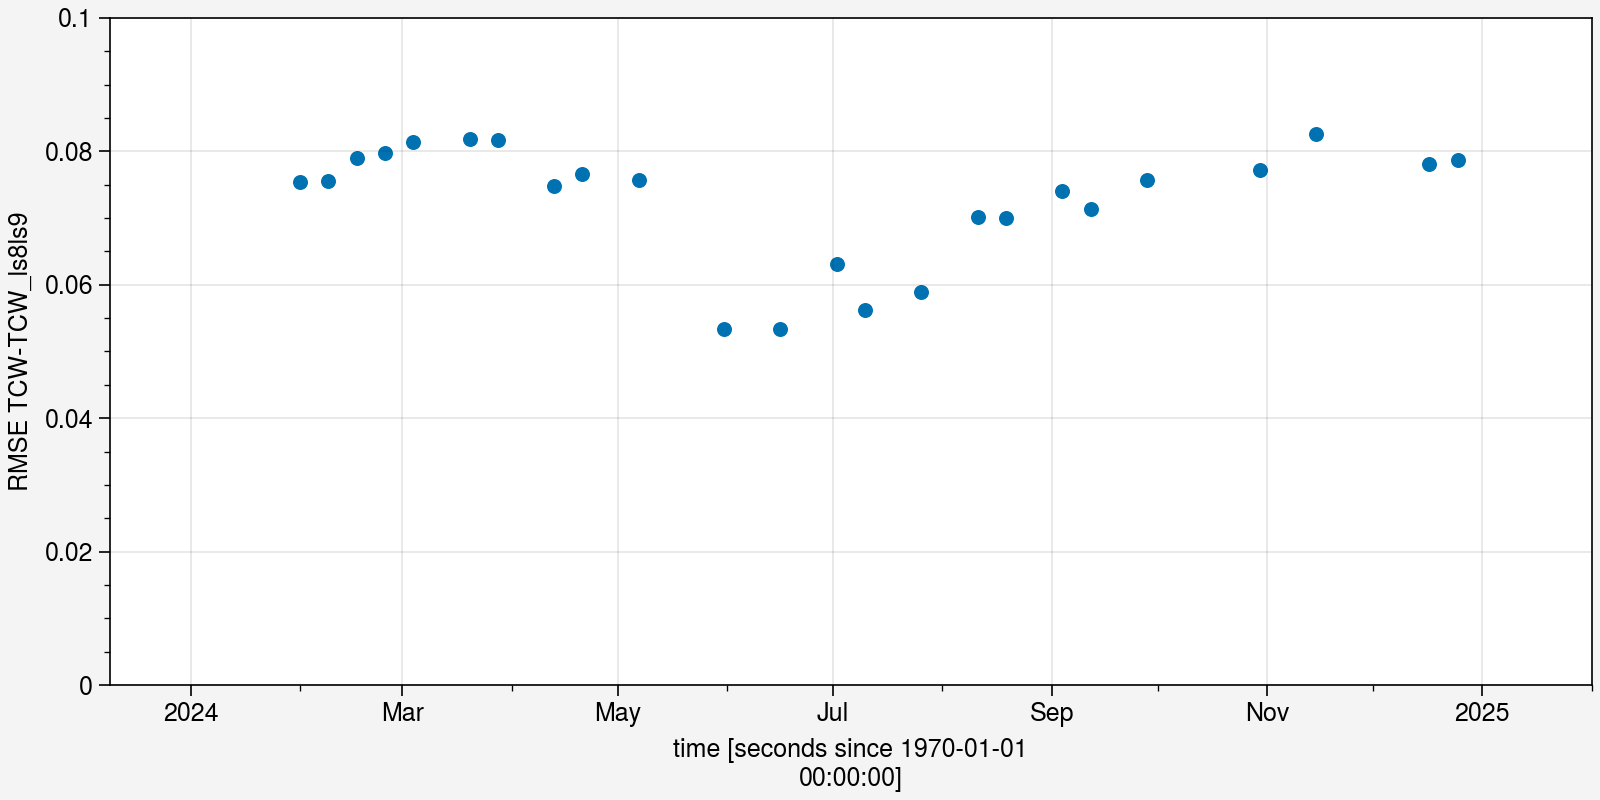

In [61]:
variables = ['TCW', 'TCW_ls8ls9']
a = ds_tc.stack(dims=['x', 'y'])[variables].dropna(
    dim='dims').groupby('time').apply(
    lambda x: xskillscore.rmse(x[variables[0]], x[variables[1]]))
f, ax = plt.subplots(figsize=(8, 4), layout='constrained')
a.plot.scatter(x='time', ax=ax)
ax.set_xlim(19700, 20120)
ax.xaxis.set_minor_locator(MonthLocator())
ax.set_ylim(0, 0.1)
ax.set_ylabel(f'RMSE {"-".join(variables)}')
ax.set_title('')


Text(0.5, 1.0, '')

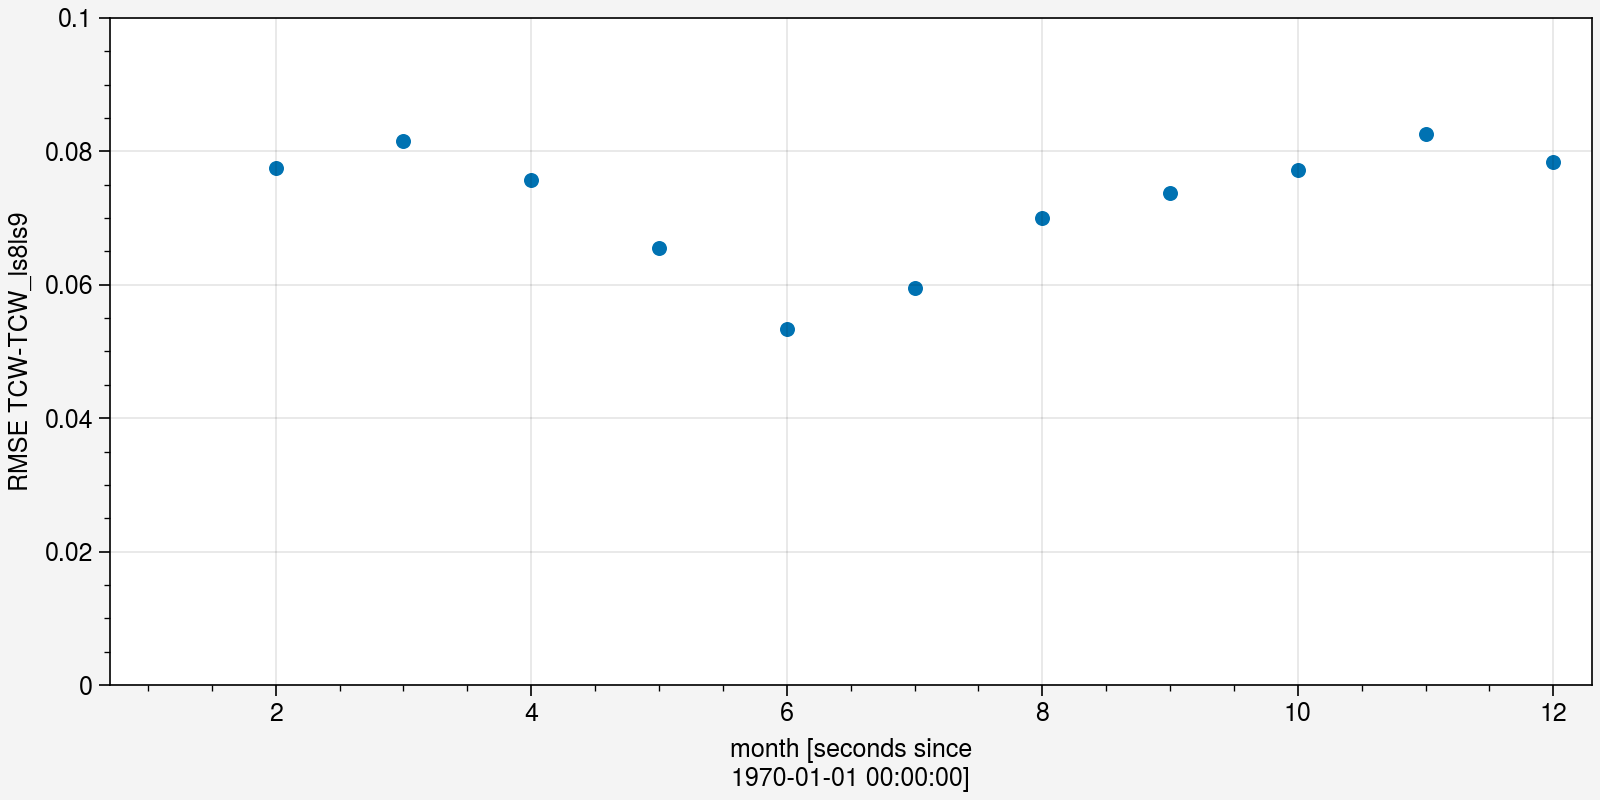

In [65]:
variables = ['TCW', 'TCW_ls8ls9']
a = ds_tc.stack(dims=['x', 'y'])[variables].dropna(
    dim='dims').groupby(ds_tc.time.dt.month).apply(
    lambda x: xskillscore.rmse(x[variables[0]], x[variables[1]]))
f, ax = plt.subplots(figsize=(8, 4), layout='constrained')
a.plot.scatter(x='month', ax=ax)
ax.set_xlim(0.7, 12.3)
# ax.xaxis.set_minor_locator(MonthLocator())
ax.set_ylim(0, 0.1)
ax.set_ylabel(f'RMSE {"-".join(variables)}')
ax.set_title('')
